In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader, random_split
from models import CondSM
from tqdm import tqdm
import math
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [35]:
data_dir = Path('/gpfs/bwfor/work/ws/hd_gy283-my_data/data_vMB_own_pde_solver/')
num_batches = 200
batch_size = 512
train_size = 0.8
val_size = 0.1
test_size = 0.1
output_idx = 0

In [36]:
voltages = []
currents = []

for i in range(num_batches):

    fp = data_dir / f'batch_{i}.npz'
    try:
        batch = np.load(fp)
    except FileNotFoundError:
        continue        

    voltages.append(batch['inputs'])

    if batch['currents'].ndim != 1:
        currents.append(batch['currents'][:, output_idx])
    else:
        currents.append(batch['currents'])
        
vs = np.concatenate(voltages, axis=0)[..., [i for i in range(voltages[0].shape[1]) if i != output_idx]]
ys = np.concatenate(currents, axis=0)

V = torch.from_numpy(vs).float()
y = torch.from_numpy(ys).unsqueeze(-1).float()

print(V.shape)
print(y.shape)

dataset = TensorDataset(V, y)

generator_1 = torch.Generator().manual_seed(32)
train_ds, val_ds, test_ds = random_split(dataset, lengths=[train_size, val_size, test_size], generator=generator_1)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"train_set: {len(train_loader.dataset)}")
print(f"val_set: {len(val_loader.dataset)}")
print(f"test_set: {len(test_loader.dataset)}")

torch.Size([300000, 7])
torch.Size([300000, 1])
train_set: 240000
val_set: 30000
test_set: 30000


In [37]:
def neg_ll(target, y):

    target = target.squeeze(-1)
    mu = y[..., 0]
    log_std = y[..., 1]
    
    N, d_out = y.shape

    sigma = F.softplus(log_std) + 1e-6
    var = sigma ** 2

    nll = 0.5 * ( 
        (target - mu) ** 2 / var 
        + 2 * torch.log(sigma) 
        + math.log(2 * math.pi) 
    )

    return nll.mean()

layer_dims = [7, 90, 90, 90, 2]
dp = 0.1
bn = True
model = CondSM(layer_dims, dropout_p=dp, batch_norm=bn)
model = model.to(device)
print('model loaded')

model loaded


In [38]:
optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=1e-3
)

train_losses = []
val_losses = []

num_epochs = 100

with tqdm(total=num_epochs, desc="Epochs") as pbar:
    for epoch in range(1, num_epochs + 1):
    
        model.train()
        running_loss = 0.0
        for v, y in train_loader:
            v = v.to(device, non_blocking=True).float()
            y = y.to(device, non_blocking=True).float()
            
            optimizer.zero_grad()

            preds = model(v)
            
            loss = neg_ll(y, preds)
            loss.backward()
            optimizer.step()
    
            running_loss += loss.item() * v.size(0)
    
        epoch_train_loss = running_loss / len(train_loader.dataset)
    
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for v, y in val_loader:

                v = v.to(device, non_blocking=True).float()
                y = y.to(device, non_blocking=True).float()

                preds = model(v)

                loss = neg_ll(y, preds)
                
                val_loss += loss.item() * v.size(0)
    
        epoch_val_loss = val_loss / len(val_loader.dataset)
    
        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
    
        pbar.set_postfix({
            "epoch": f"{epoch}/{num_epochs}",
            "train": f"{epoch_train_loss:.4f}",
            "val": f"{epoch_val_loss:.4f}"
        })
        pbar.update(1)

torch.save({
    "model_state_dict": model.state_dict(),
    "layer_dims": layer_dims,
    "dropout": dp,
    "batch_norm": bn,
    "train_losses": train_losses,
    "val_losses": val_losses
}, f"/gpfs/bwfor/work/ws/hd_gy283-my_data/models/sm_vMB_na=200.pth")

print(f"Model has been saved!")

Epochs: 100%|██████████| 100/100 [02:07<00:00,  1.27s/it, epoch=100/100, train=-2.6120, val=-2.9252]

Model has been saved!


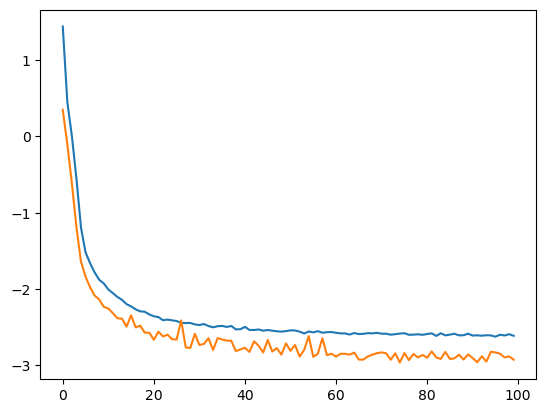

In [39]:
plt.plot(train_losses)
plt.plot(val_losses)